# Daily Challenge: Building Your First Neural Network on the MNIST Dataset

Week 9, Day 4

Goal: build, train and evaluate a fully connected neural network that recognises handwritten digits (0–9), then run a basic hyperparameter tuning experiment.

## Setup

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # hide TensorFlow C++ info logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
tf.keras.utils.set_random_seed(SEED)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 1. Load and Preprocess the MNIST Dataset

In [2]:
# MNIST comes already split into a training set (60,000 images) and a test set (10,000 images)
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)
print("Pixel range before normalisation:", x_train.min(), "-", x_train.max())

Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)
Pixel range before normalisation: 0 - 255


In [3]:
# Normalise pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print("Pixel range after normalisation:", x_train.min(), "-", x_train.max())

# One-hot encode the labels: 7 -> [0,0,0,0,0,0,0,1,0,0]
y_train_oh = to_categorical(y_train, 10)
y_test_oh = to_categorical(y_test, 10)
print("One-hot labels:", y_train_oh.shape, y_test_oh.shape)
print("Example:", y_train[0], "->", y_train_oh[0])

Pixel range after normalisation: 0.0 - 1.0
One-hot labels: (60000, 10) (10000, 10)
Example: 5 -> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


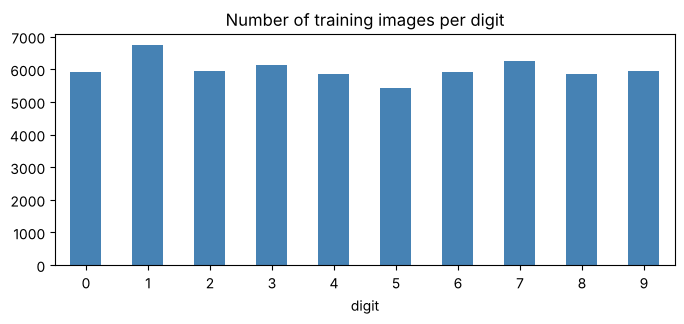

In [4]:
# Class balance
counts = pd.Series(y_train).value_counts().sort_index()
plt.figure(figsize=(8, 3))
counts.plot(kind='bar', color='steelblue', rot=0)
plt.title('Number of training images per digit')
plt.xlabel('digit')
plt.show()

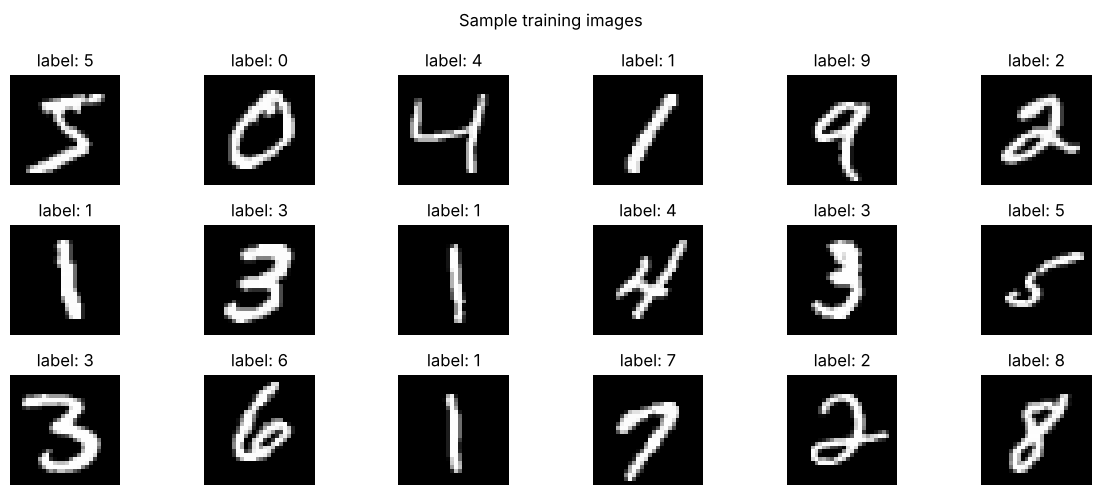

In [5]:
# Sample images with their labels
plt.figure(figsize=(12, 5))
for i in range(18):
    plt.subplot(3, 6, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"label: {y_train[i]}")
    plt.axis('off')
plt.suptitle('Sample training images')
plt.tight_layout()
plt.show()

The 10 digits are roughly balanced (about 5,400–6,700 images each), so accuracy is a meaningful metric. Each image is 28×28 grayscale pixels; after normalisation the values are between 0 and 1, which keeps the inputs on a small, uniform scale and makes training more stable.

## 2. Build a Fully Connected Neural Network

In [6]:
def build_model(hidden_units=(256, 128), learning_rate=0.001, dropout=0.0):
    model = models.Sequential([layers.Input(shape=(28, 28)), layers.Flatten()])  # 28x28 -> 784
    for units in hidden_units:
        model.add(layers.Dense(units, activation='relu'))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Two hidden layers (256 and 128 neurons, ReLU) + softmax output over 10 classes
model = build_model(hidden_units=(256, 128))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

- **Flatten** turns each 28×28 image into a vector of 784 values.
- **Two hidden Dense layers (256 and 128 neurons, ReLU)** learn intermediate representations (strokes, loops, curves).
- **Output Dense layer (10 neurons, softmax)** gives a probability for each digit; they sum to 1.
- **Loss: categorical cross-entropy**, which matches one-hot labels and softmax outputs; **optimizer: Adam**; **metric: accuracy**.

## 3. Train the Neural Network

In [7]:
# 10 epochs, with 10% of the training set held out as a validation set
history = model.fit(x_train, y_train_oh, epochs=10, batch_size=128, validation_split=0.1, verbose=2)

Epoch 1/10


422/422 - 3s - 6ms/step - accuracy: 0.9157 - loss: 0.2904 - val_accuracy: 0.9643 - val_loss: 0.1162


Epoch 2/10


422/422 - 1s - 3ms/step - accuracy: 0.9659 - loss: 0.1158 - val_accuracy: 0.9727 - val_loss: 0.0889


Epoch 3/10


...

422/422 - 1s - 4ms/step - accuracy: 0.9939 - loss: 0.0194 - val_accuracy: 0.9738 - val_loss: 0.1004


Epoch 9/10


422/422 - 2s - 4ms/step - accuracy: 0.9948 - loss: 0.0164 - val_accuracy: 0.9730 - val_loss: 0.1083


Epoch 10/10


422/422 - 1s - 3ms/step - accuracy: 0.9961 - loss: 0.0123 - val_accuracy: 0.9742 - val_loss: 0.1043


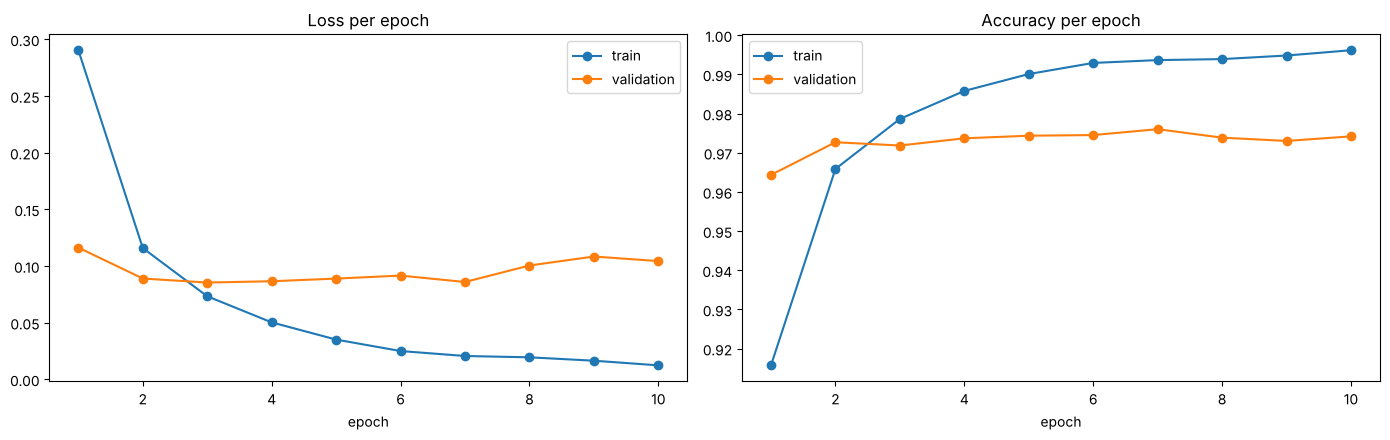

,accuracy,loss,val_accuracy,val_loss
1,0.9157,0.2904,0.9643,0.1162
2,0.9659,0.1158,0.9727,0.0889
3,0.9786,0.0733,0.9718,0.0854
4,0.9858,0.0502,0.9737,0.0865
5,0.9901,0.0351,0.9743,0.0889
6,0.9929,0.0249,0.9745,0.0915
7,0.9936,0.0206,0.9760,0.0859
8,0.9939,0.0194,0.9738,0.1004
9,0.9948,0.0164,0.9730,0.1083
10,0.9961,0.0123,0.9742,0.1043


Best validation accuracy: 0.9760 at epoch 7


In [8]:
hist = pd.DataFrame(history.history)
hist.index = hist.index + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(hist['loss'], 'o-', label='train')
axes[0].plot(hist['val_loss'], 'o-', label='validation')
axes[0].set_title('Loss per epoch')
axes[0].set_xlabel('epoch')
axes[0].legend()
axes[1].plot(hist['accuracy'], 'o-', label='train')
axes[1].plot(hist['val_accuracy'], 'o-', label='validation')
axes[1].set_title('Accuracy per epoch')
axes[1].set_xlabel('epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

display(hist.round(4))
print(f"Best validation accuracy: {hist['val_accuracy'].max():.4f} at epoch {hist['val_accuracy'].idxmax()}")

**Loss and accuracy trends:**
- The **training loss** decreases at every epoch (0.29 → 0.012) and the training accuracy climbs to 99.6%.
- The **validation accuracy** rises quickly during the first 2 epochs (96.4% → 97.3%), then plateaus around 97.3–97.6% (best: 97.6% at epoch 7).
- The **validation loss** reaches its minimum around epoch 3 (≈ 0.085) and then slowly *increases* again (≈ 0.10 at epoch 10), while the training loss keeps going down.

This growing gap between training (99.6%) and validation (97.4%) is a sign of **overfitting**: after a few epochs the network starts memorising the training images instead of learning more general patterns. Early stopping around epoch 3–7 or regularisation (dropout) would help; we test dropout in the tuning section.

## 4. Evaluate the Model's Performance

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}  ({(1 - test_acc) * len(x_test):.0f} misclassified images out of {len(x_test)})")

y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
print()
print(classification_report(y_test, y_pred, digits=4))

Test loss: 0.1021
Test accuracy: 0.9730  (270 misclassified images out of 10000)



              precision    recall  f1-score   support

           0     0.9788    0.9908    0.9848       980
           1     0.9885    0.9885    0.9885      1135
           2     0.9729    0.9758    0.9744      1032
           3     0.9486    0.9871    0.9675      1010
           4     0.9717    0.9786    0.9751       982
           5     0.9871    0.9428    0.9644       892
           6     0.9852    0.9760    0.9806       958
           7     0.9880    0.9630    0.9754      1028
           8     0.9297    0.9774    0.9530       974
           9     0.9825    0.9455    0.9636      1009

    accuracy                         0.9730     10000
   macro avg     0.9733    0.9726    0.9727     10000
weighted avg     0.9735    0.9730    0.9730     10000



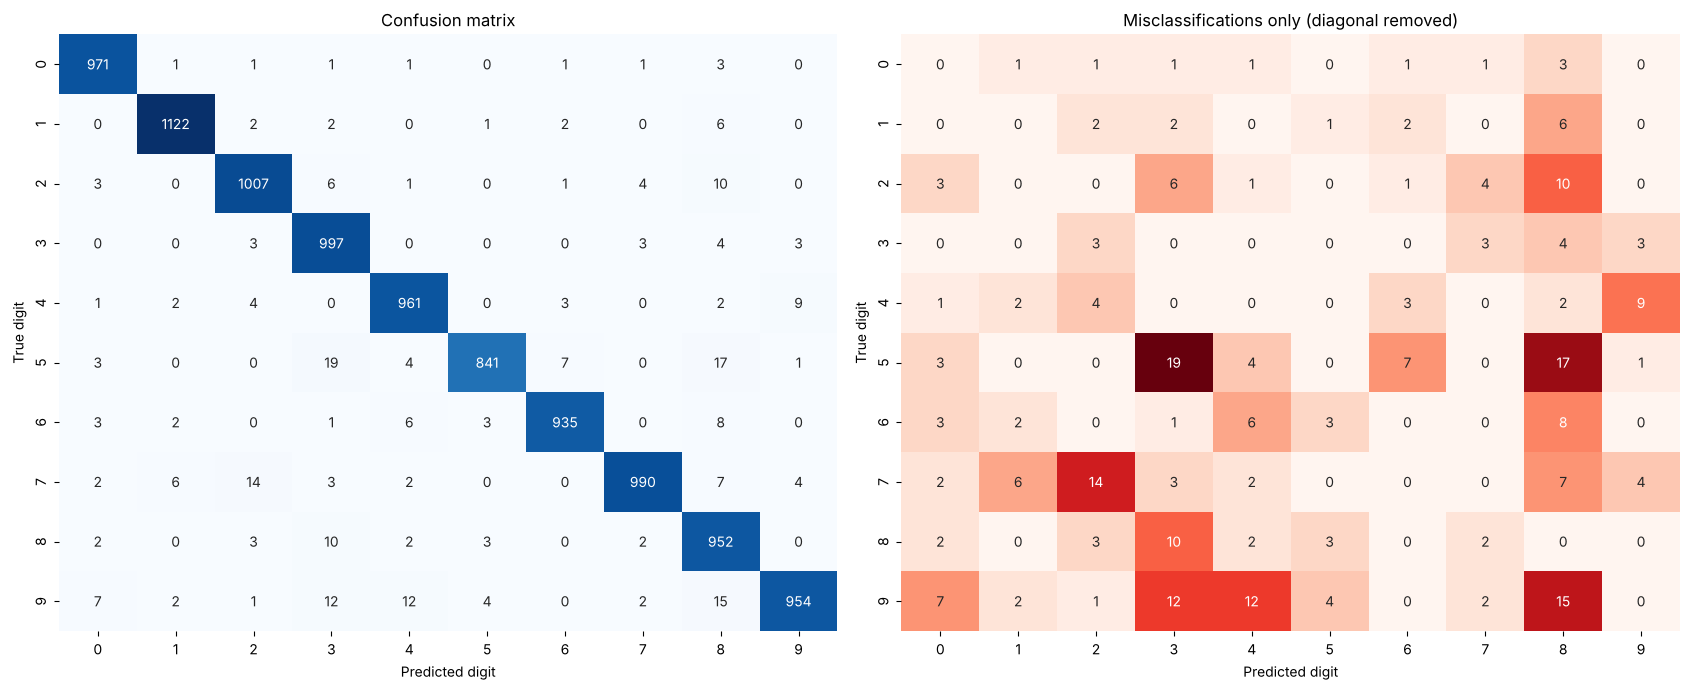

In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_xlabel('Predicted digit')
axes[0].set_ylabel('True digit')
axes[0].set_title('Confusion matrix')

# Same matrix with the diagonal removed, to highlight the misclassifications only
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)
sns.heatmap(cm_errors, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[1])
axes[1].set_xlabel('Predicted digit')
axes[1].set_ylabel('True digit')
axes[1].set_title('Misclassifications only (diagonal removed)')
plt.tight_layout()
plt.show()

,test images,errors,error rate
5,892,51,5.72%
9,1009,55,5.45%
7,1028,38,3.70%
2,1032,25,2.42%
6,958,23,2.40%
8,974,22,2.26%
4,982,21,2.14%
3,1010,13,1.29%
1,1135,13,1.15%
0,980,9,0.92%


Most frequent confusions (true -> predicted):
  5 -> 3: 19 times
  5 -> 8: 17 times
  9 -> 8: 15 times
  7 -> 2: 14 times
  9 -> 4: 12 times
  9 -> 3: 12 times


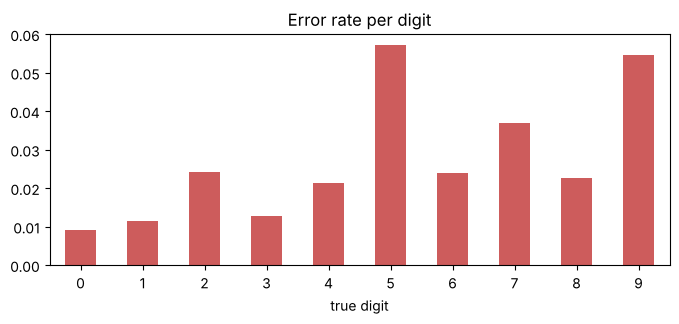

In [11]:
# Which digits does the model struggle with the most?
per_digit = pd.DataFrame({
    'test images': cm.sum(axis=1),
    'errors': cm.sum(axis=1) - np.diag(cm),
})
per_digit['error rate'] = per_digit['errors'] / per_digit['test images']
per_digit = per_digit.sort_values('error rate', ascending=False)
display(per_digit.style.format({'error rate': '{:.2%}'}))

pairs = [(cm_errors[i, j], i, j) for i in range(10) for j in range(10) if cm_errors[i, j] > 0]
pairs.sort(reverse=True)
print("Most frequent confusions (true -> predicted):")
for n, i, j in pairs[:6]:
    print(f"  {i} -> {j}: {n} times")

per_digit['error rate'].sort_index().plot(kind='bar', figsize=(8, 3), color='indianred', rot=0)
plt.title('Error rate per digit')
plt.xlabel('true digit')
plt.show()

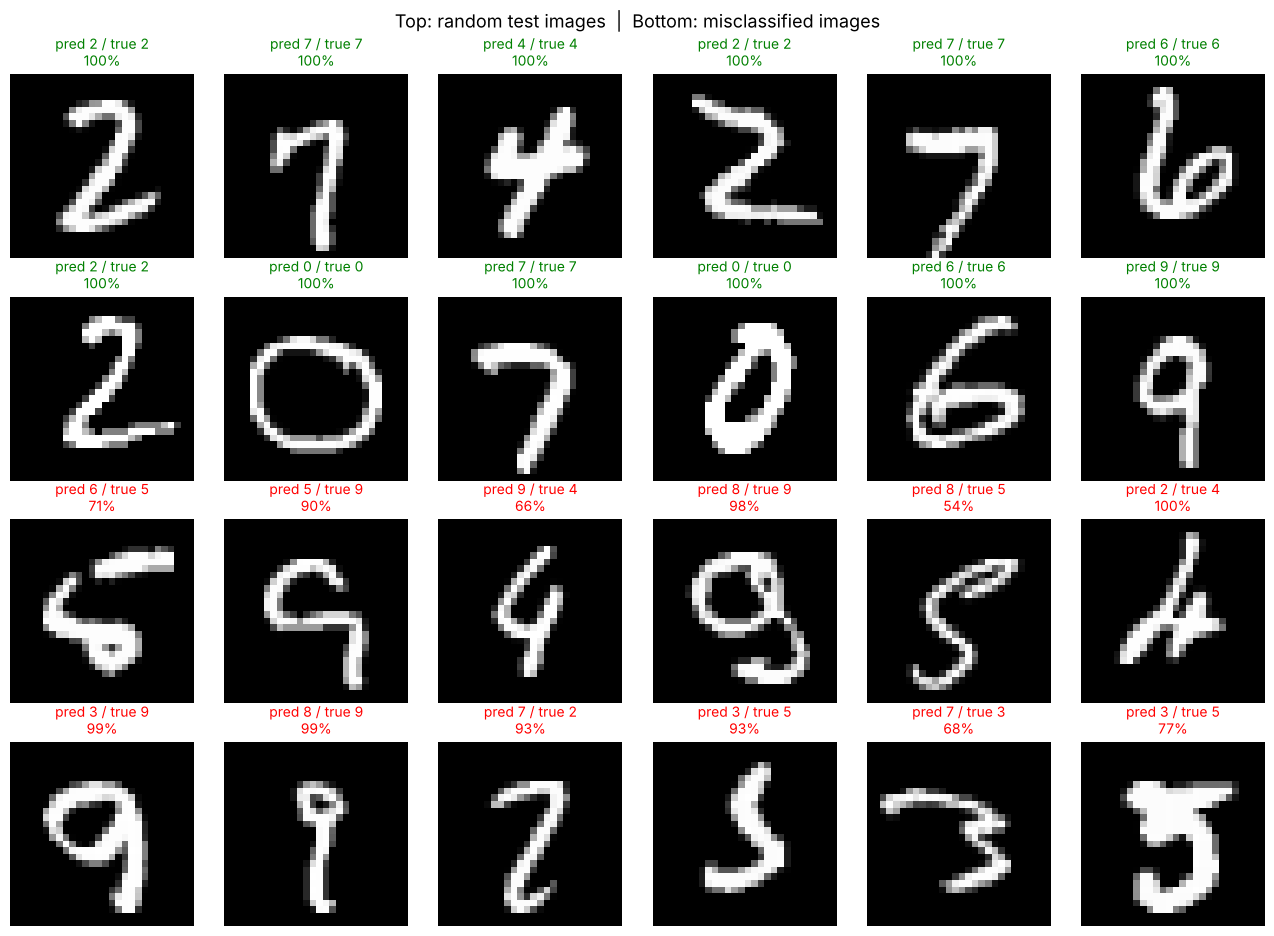

In [12]:
# Visualise predictions on random test images, and some of the mistakes
rng = np.random.default_rng(SEED)
idx = rng.choice(len(x_test), size=12, replace=False)
errors = np.where(y_pred != y_test)[0][:12]

fig, axes = plt.subplots(4, 6, figsize=(13, 9.5))
for ax, k in zip(axes[:2].ravel(), idx):
    ax.imshow(x_test[k], cmap='gray')
    ok = y_pred[k] == y_test[k]
    ax.set_title(f"pred {y_pred[k]} / true {y_test[k]}\n{y_prob[k].max():.0%}", color='green' if ok else 'red', fontsize=10)
    ax.axis('off')
for ax, k in zip(axes[2:].ravel(), errors):
    ax.imshow(x_test[k], cmap='gray')
    ax.set_title(f"pred {y_pred[k]} / true {y_test[k]}\n{y_prob[k].max():.0%}", color='red', fontsize=10)
    ax.axis('off')
fig.suptitle('Top: random test images  |  Bottom: misclassified images', fontsize=13)
plt.tight_layout()
plt.show()

**Which digits does the model struggle with?**

- Overall test accuracy: **97.3%** (270 errors out of 10,000 images).
- The hardest digits are **5** (recall 94.3%, ~5.7% of the 5s misclassified) and **9** (recall 94.6%), followed by **7** (96.3%). The easiest are **0** and **1** (> 98.8%).
- The most frequent confusions are **5 → 3** (19 times), **5 → 8** (17), **9 → 8** (15), **7 → 2** (14), **9 → 4** and **9 → 3** (12 each). These digits share strokes: a 5 with a closed loop looks like a 3 or an 8, a 9 written with an open top looks like a 4, a 7 with a bar looks like a 2.
- **8** has the lowest *precision* (93.0%): the model often answers "8" when it is unsure, because an 8 contains the strokes of many other digits.
- The misclassified images shown above are often badly written digits that a human could also hesitate on, and the model is usually less confident on them.

A fully connected network sees the image as a flat list of 784 pixels and ignores the 2D structure; a convolutional neural network (CNN) would capture local shapes better and reduce these confusions.

## 5. Hyperparameter Tuning Experiment

We compare a few configurations, changing one thing at a time: the size of the hidden layers, the learning rate, and adding dropout (regularisation). Each configuration is trained for 10 epochs with the same validation split, and we keep the one with the best validation accuracy; the test set is only used at the end, to evaluate the chosen model.

In [13]:
configs = {
    'baseline (256-128, lr=0.001)': dict(hidden_units=(256, 128), learning_rate=0.001),
    'smaller (64-32)': dict(hidden_units=(64, 32), learning_rate=0.001),
    'larger (512-256)': dict(hidden_units=(512, 256), learning_rate=0.001),
    'lr = 0.01': dict(hidden_units=(256, 128), learning_rate=0.01),
    'lr = 0.0001': dict(hidden_units=(256, 128), learning_rate=0.0001),
    'dropout 0.2': dict(hidden_units=(256, 128), learning_rate=0.001, dropout=0.2),
    'larger + dropout 0.2': dict(hidden_units=(512, 256), learning_rate=0.001, dropout=0.2),
}

results, histories, trained = {}, {}, {}
for name, params in configs.items():
    tf.keras.utils.set_random_seed(SEED)
    m = build_model(**params)
    h = m.fit(x_train, y_train_oh, epochs=10, batch_size=128, validation_split=0.1, verbose=0)
    histories[name] = h.history
    trained[name] = m
    results[name] = {
        'params': m.count_params(),
        'best val_accuracy': max(h.history['val_accuracy']),
        'final val_accuracy': h.history['val_accuracy'][-1],
        'final train_accuracy': h.history['accuracy'][-1],
        'final val_loss': h.history['val_loss'][-1],
    }
    print(f"{name:<30} val_acc = {results[name]['final val_accuracy']:.4f}")

results_df = pd.DataFrame(results).T.sort_values('final val_accuracy', ascending=False)
results_df['overfitting gap'] = results_df['final train_accuracy'] - results_df['final val_accuracy']
display(results_df.style.format({'params': '{:,.0f}', 'best val_accuracy': '{:.4f}', 'final val_accuracy': '{:.4f}',
                                 'final train_accuracy': '{:.4f}', 'final val_loss': '{:.4f}', 'overfitting gap': '{:.4f}'}))

baseline (256-128, lr=0.001)   val_acc = 0.9742


smaller (64-32)                val_acc = 0.9712


larger (512-256)               val_acc = 0.9780


lr = 0.01                      val_acc = 0.9727


lr = 0.0001                    val_acc = 0.9710


dropout 0.2                    val_acc = 0.9815


larger + dropout 0.2           val_acc = 0.9793


,params,best val_accuracy,final val_accuracy,final train_accuracy,final val_loss,overfitting gap
dropout 0.2,"235,146",0.9832,0.9815,0.9876,0.0699,0.0061
larger + dropout 0.2,"535,818",0.9813,0.9793,0.9918,0.0901,0.0124
larger (512-256),"535,818",0.9780,0.9780,0.9957,0.0979,0.0177
"baseline (256-128, lr=0.001)","235,146",0.9760,0.9742,0.9961,0.1043,0.0220
lr = 0.01,"235,146",0.9733,0.9727,0.9816,0.1482,0.0090
smaller (64-32),"52,650",0.9725,0.9712,0.9874,0.1042,0.0163
lr = 0.0001,"235,146",0.9710,0.9710,0.9728,0.0992,0.0018


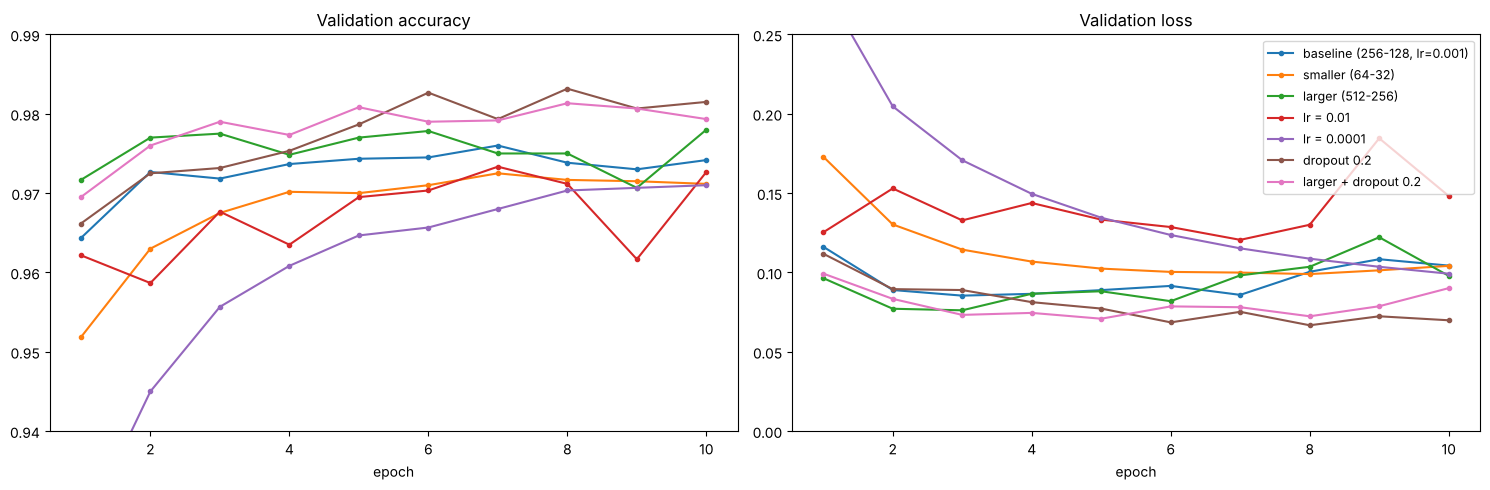

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, h in histories.items():
    axes[0].plot(range(1, 11), h['val_accuracy'], 'o-', markersize=3, label=name)
    axes[1].plot(range(1, 11), h['val_loss'], 'o-', markersize=3, label=name)
axes[0].set_title('Validation accuracy')
axes[0].set_xlabel('epoch')
axes[0].set_ylim(0.94, 0.99)
axes[1].set_title('Validation loss')
axes[1].set_xlabel('epoch')
axes[1].set_ylim(0, 0.25)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
best_name = results_df.index[0]
best_model = trained[best_name]
best_test_loss, best_test_acc = best_model.evaluate(x_test, y_test_oh, verbose=0)
print(f"Best configuration (validation): {best_name}")
print(f"Test accuracy - baseline: {test_acc:.4f} | best tuned model: {best_test_acc:.4f}")
best_errors = int(round((1 - best_test_acc) * len(x_test)))
base_errors = int(round((1 - test_acc) * len(x_test)))
print(f"Misclassified test images: {base_errors} -> {best_errors}")

Best configuration (validation): dropout 0.2
Test accuracy - baseline: 0.9730 | best tuned model: 0.9807
Misclassified test images: 270 -> 193


**Tuning results:**

| Configuration | Validation accuracy |
|---|---|
| **Dropout 0.2 (256-128)** | **0.9815** |
| Larger (512-256) + dropout 0.2 | 0.9793 |
| Larger (512-256) | 0.9780 |
| Baseline (256-128, lr = 0.001) | 0.9742 |
| lr = 0.01 | 0.9727 |
| Smaller (64-32) | 0.9712 |
| lr = 0.0001 | 0.9710 |

- **Dropout** gives the biggest improvement: by randomly switching off 20% of the neurons during training, it prevents the network from memorising the training set and reduces the overfitting seen in section 3.
- **Network size:** a smaller network (64-32) underfits a little, while a larger one (512-256) helps slightly but overfits more without dropout.
- **Learning rate:** 0.001 (Adam's default) is the best compromise; 0.01 makes training unstable, and 0.0001 learns too slowly to converge within 10 epochs.

The best configuration (**256-128 with dropout 0.2**) reaches **98.1% accuracy on the test set**, against 97.3% for the baseline: the number of misclassified images drops from **270 to 193** (−29% errors).

## Conclusion

We built a fully connected network (784 → 256 → 128 → 10) that recognises handwritten digits with **97.3% test accuracy** after 10 epochs, and **98.1%** after a simple hyperparameter tuning (adding dropout). The main difficulties are the digits 5, 9 and 7, which are confused with digits that share similar strokes (3, 8, 4, 2). Next steps to go further: early stopping, data augmentation, and above all a CNN, which typically reaches more than 99% on MNIST.